In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import random
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
df = pd.read_csv(r"C:\Users\admin\Downloads\classData.csv")   # <-- update the path/filename if needed

print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
display(df.head())
print("\nColumn dtypes:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nStatistical summary:")
display(df.describe())

Shape of dataset: (7861, 10)

First 5 rows:


,G,C,B,A,Ia,Ib,Ic,Va,Vb,Vc
0,1,0,0,1,-151.291812,-9.677452,85.800162,0.400750,-0.132935,-0.267815
1,1,0,0,1,-336.186183,-76.283262,18.328897,0.312732,-0.123633,-0.189099
2,1,0,0,1,-502.891583,-174.648023,-80.924663,0.265728,-0.114301,-0.151428
3,1,0,0,1,-593.941905,-217.703359,-124.891924,0.235511,-0.104940,-0.130570
4,1,0,0,1,-643.663617,-224.159427,-132.282815,0.209537,-0.095554,-0.113983



Column dtypes:
G       int64
C       int64
B       int64
A       int64
Ia    float64
Ib    float64
Ic    float64
Va    float64
Vb    float64
Vc    float64
dtype: object

Missing values per column:
G     0
C     0
B     0
A     0
Ia    0
Ib    0
Ic    0
Va    0
Vb    0
Vc    0
dtype: int64

Statistical summary:


,G,C,B,A,Ia,Ib,Ic,Va,Vb,Vc
count,7861.000000,7861.000000,7861.000000,7861.000000,7861.000000,7861.000000,7861.000000,7861.000000,7861.000000,7861.000000
mean,0.432006,0.411271,0.555527,0.571429,13.721194,-44.845268,34.392394,-0.007667,0.001152,0.006515
std,0.495387,0.492095,0.496939,0.494903,464.741671,439.269195,371.107412,0.289150,0.313437,0.307897
min,0.000000,0.000000,0.000000,0.000000,-883.542316,-900.526951,-883.357762,-0.620748,-0.608016,-0.612709
25%,0.000000,0.000000,0.000000,0.000000,-119.802518,-271.845947,-61.034219,-0.130287,-0.159507,-0.215977
50%,0.000000,0.000000,1.000000,1.000000,2.042805,5.513317,-4.326711,-0.005290,0.001620,0.009281
75%,1.000000,1.000000,1.000000,1.000000,227.246377,91.194282,49.115141,0.111627,0.153507,0.239973
max,1.000000,1.000000,1.000000,1.000000,885.738571,889.868884,901.274261,0.595342,0.627875,0.600179


In [3]:
FAULT_MAP = {
    (0, 0, 0, 0): 'No Fault',
    (1, 0, 0, 1): 'LG',
    (0, 0, 1, 1): 'LL',
    (1, 0, 1, 1): 'LLG',
    (0, 1, 1, 1): 'LLL',
    (1, 1, 1, 1): 'LLLG',
}

def map_fault(row):
    key = (int(row['G']), int(row['C']), int(row['B']), int(row['A']))
    return FAULT_MAP.get(key, 'Unknown')

df['Fault_Type'] = df.apply(map_fault, axis=1)
print("Fault type distribution:")
print(df['Fault_Type'].value_counts())

unknown_count = (df['Fault_Type'] == 'Unknown').sum()
if unknown_count > 0:
    print(f"\nWarning: {unknown_count} rows had a G/C/B/A combination not in FAULT_MAP.")

Fault type distribution:
Fault_Type
No Fault    2365
LLG         1134
LLLG        1133
LG          1129
LLL         1096
Unknown     1004
Name: count, dtype: int64



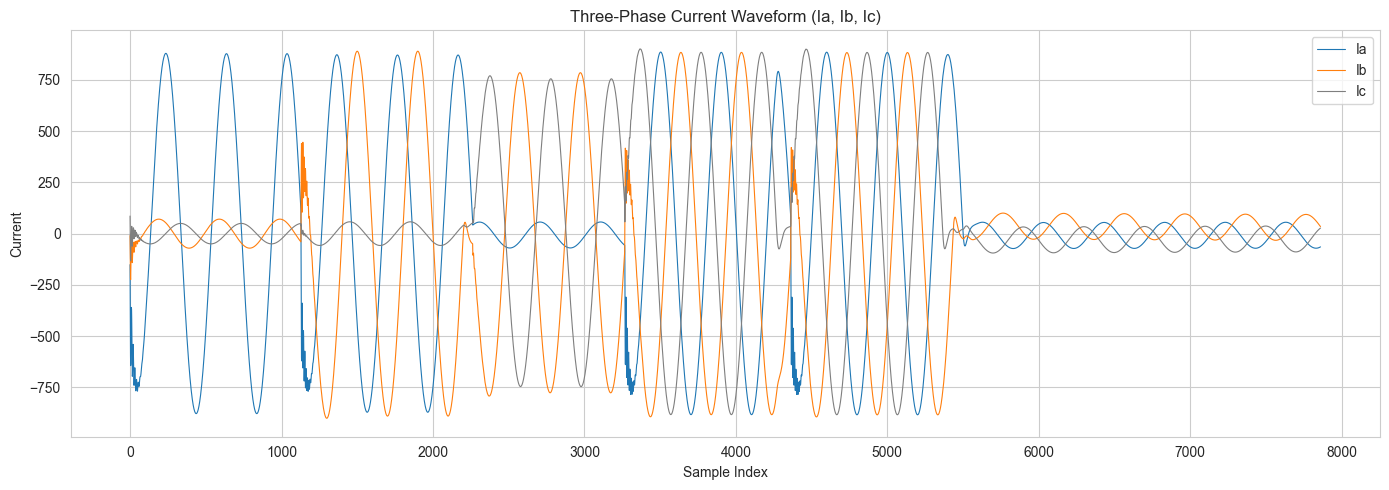

In [4]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['Ia'], label='Ia', color='#1f77b4', linewidth=0.8)
plt.plot(df.index, df['Ib'], label='Ib', color='#ff7f0e', linewidth=0.8)
plt.plot(df.index, df['Ic'], label='Ic', color='#7f7f7f', linewidth=0.8)
plt.title('Three-Phase Current Waveform (Ia, Ib, Ic)')
plt.xlabel('Sample Index')
plt.ylabel('Current')
plt.legend()
plt.tight_layout()
plt.show()

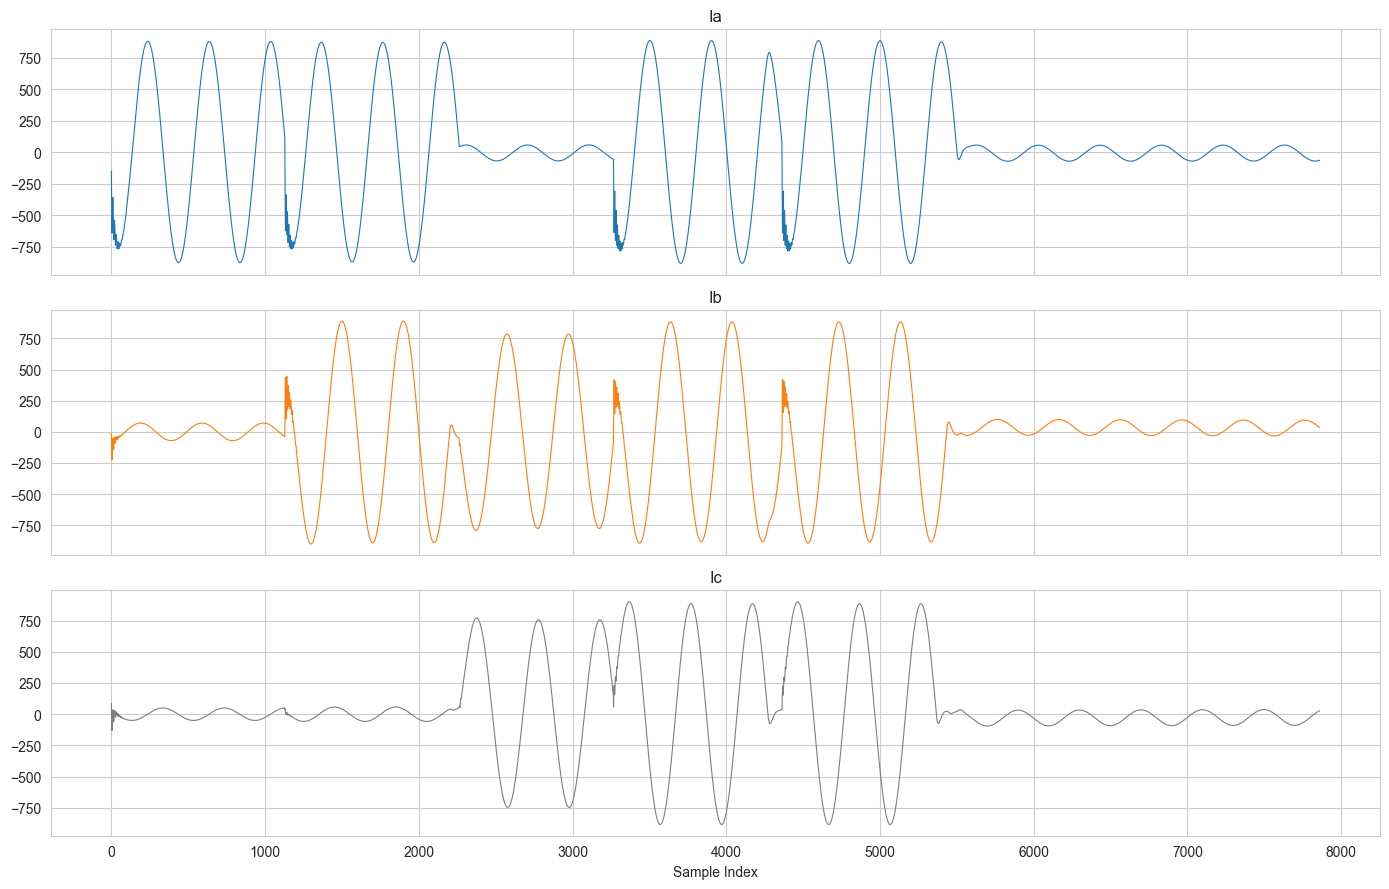

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
axes[0].plot(df.index, df['Ia'], color='#1f77b4', linewidth=0.8)
axes[0].set_title('Ia')
axes[1].plot(df.index, df['Ib'], color='#ff7f0e', linewidth=0.8)
axes[1].set_title('Ib')
axes[2].plot(df.index, df['Ic'], color='#7f7f7f', linewidth=0.8)
axes[2].set_title('Ic')
axes[2].set_xlabel('Sample Index')
plt.tight_layout()
plt.show()

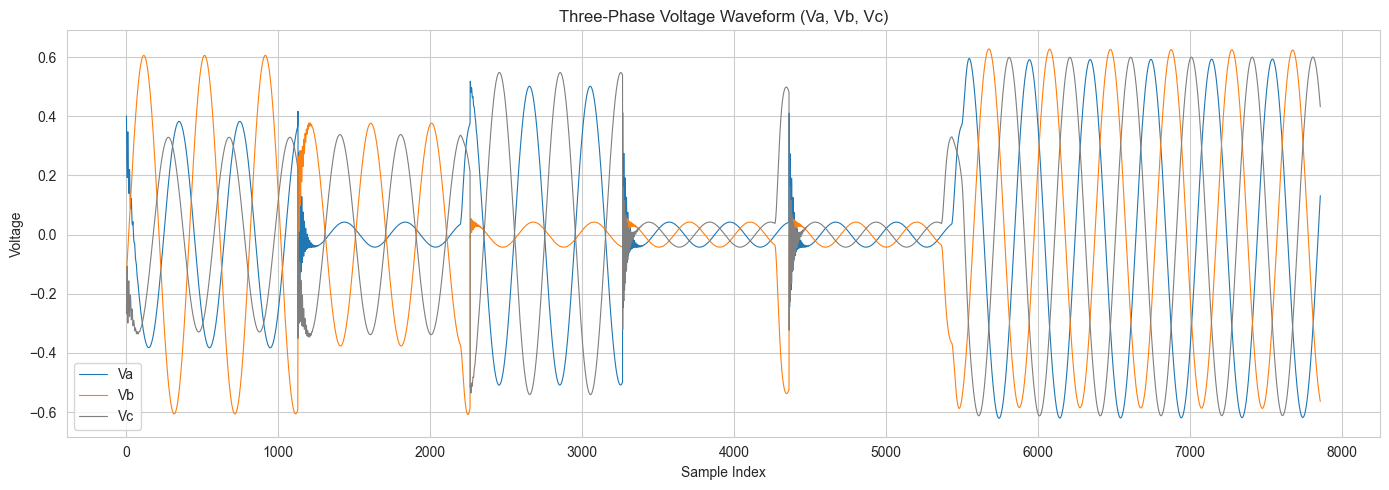

In [6]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['Va'], label='Va', color='#1f77b4', linewidth=0.8)
plt.plot(df.index, df['Vb'], label='Vb', color='#ff7f0e', linewidth=0.8)
plt.plot(df.index, df['Vc'], label='Vc', color='#7f7f7f', linewidth=0.8)
plt.title('Three-Phase Voltage Waveform (Va, Vb, Vc)')
plt.xlabel('Sample Index')
plt.ylabel('Voltage')
plt.legend()
plt.tight_layout()
plt.show()

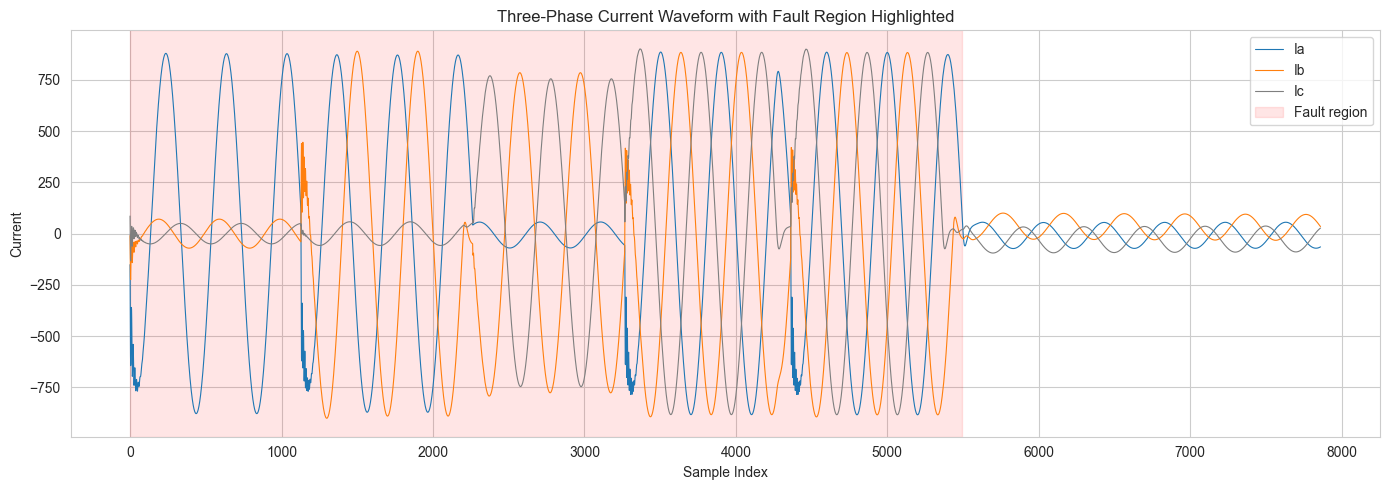

In [7]:
fault_mask = df['Fault_Type'] != 'No Fault'

plt.figure(figsize=(14, 5))
plt.plot(df.index, df['Ia'], label='Ia', color='#1f77b4', linewidth=0.8)
plt.plot(df.index, df['Ib'], label='Ib', color='#ff7f0e', linewidth=0.8)
plt.plot(df.index, df['Ic'], label='Ic', color='#7f7f7f', linewidth=0.8)
if fault_mask.any():
    plt.axvspan(df.index[fault_mask][0], df.index[fault_mask][-1],
                color='red', alpha=0.1, label='Fault region')
plt.title('Three-Phase Current Waveform with Fault Region Highlighted')
plt.xlabel('Sample Index')
plt.ylabel('Current')
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
feature_cols = ['Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc']

rows_before_na = df.shape[0]
df = df.dropna().reset_index(drop=True)
rows_after_na = df.shape[0]
print(f"Rows before null handling: {rows_before_na}")
print(f"Rows after null handling:  {rows_after_na}")
print(f"Rows dropped (nulls):      {rows_before_na - rows_after_na}")

rows_before_outliers = df.shape[0]
class_dist_before = df['Fault_Type'].value_counts()

df_clean = df.copy()
for col in feature_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

df_clean = df_clean.reset_index(drop=True)
rows_after_outliers = df_clean.shape[0]

print(f"\nRows before outlier removal: {rows_before_outliers}")
print(f"Rows after outlier removal:  {rows_after_outliers}")
print(f"Rows removed as outliers:    {rows_before_outliers - rows_after_outliers}")
print("\nClass distribution BEFORE:", class_dist_before.to_dict())
print("Class distribution AFTER: ", df_clean['Fault_Type'].value_counts().to_dict())

df = df_clean

Rows before null handling: 7861
Rows after null handling:  7861
Rows dropped (nulls):      0

Rows before outlier removal: 7861
Rows after outlier removal:  3895
Rows removed as outliers:    3966

Class distribution BEFORE: {'No Fault': 2365, 'LLG': 1134, 'LLLG': 1133, 'LG': 1129, 'LLL': 1096, 'Unknown': 1004}
Class distribution AFTER:  {'No Fault': 2365, 'LG': 668, 'LLG': 467, 'Unknown': 175, 'LLL': 113, 'LLLG': 107}


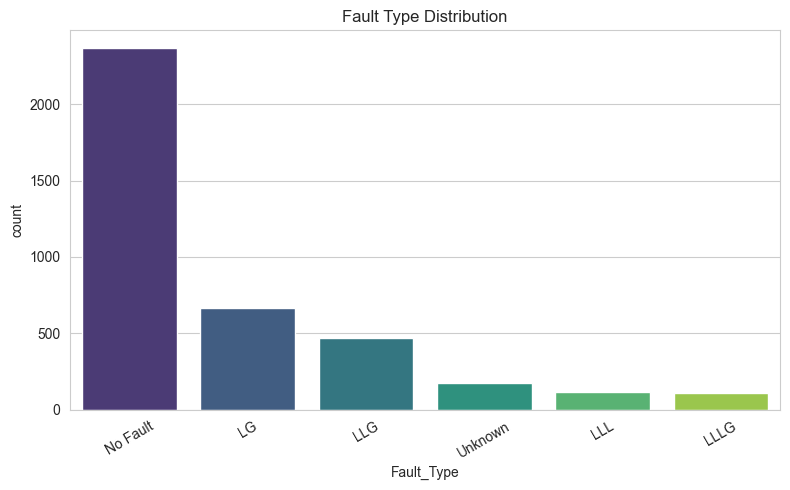

In [9]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Fault_Type', order=df['Fault_Type'].value_counts().index, palette='viridis')
plt.title('Fault Type Distribution')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

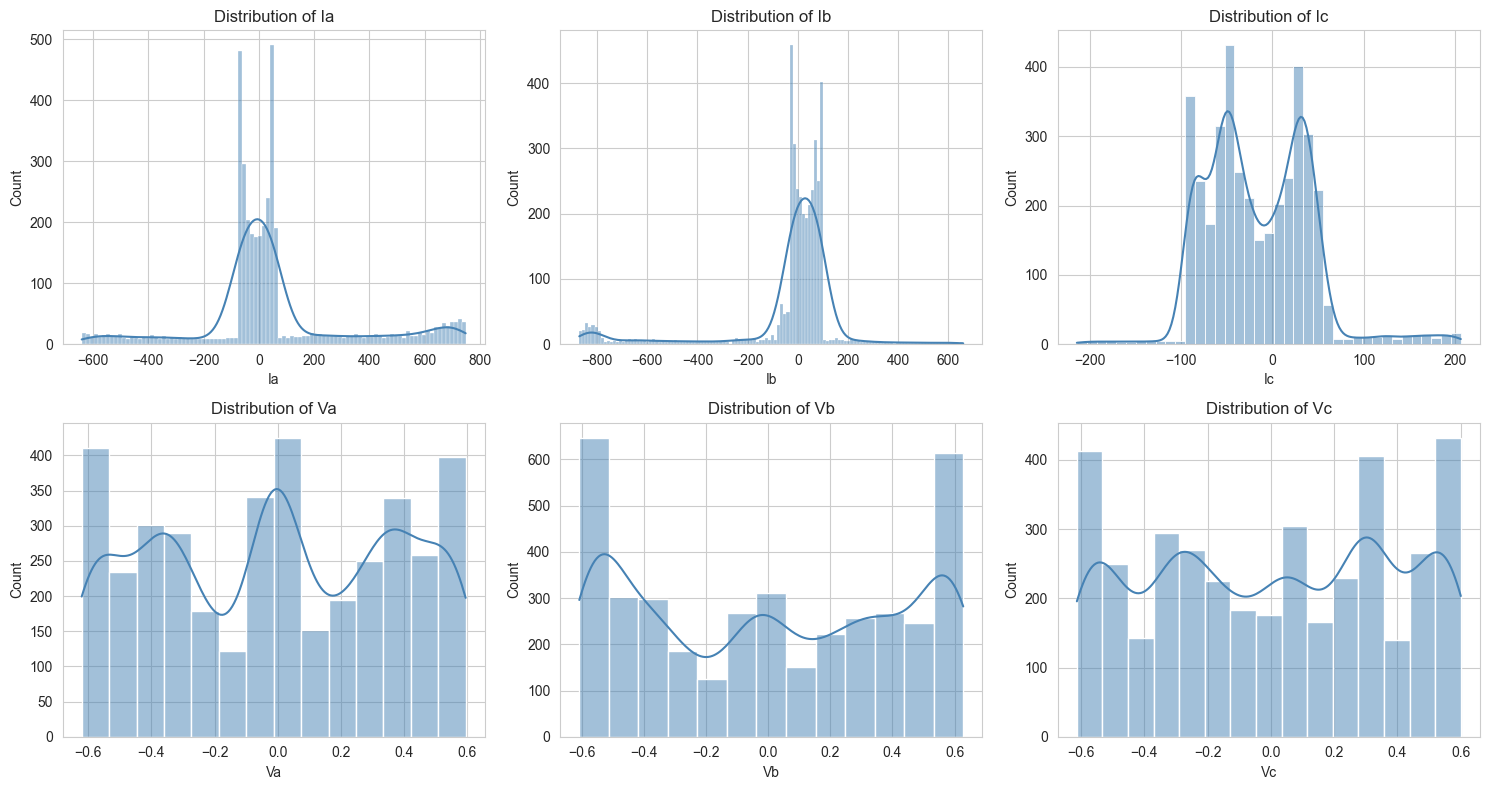

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), feature_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

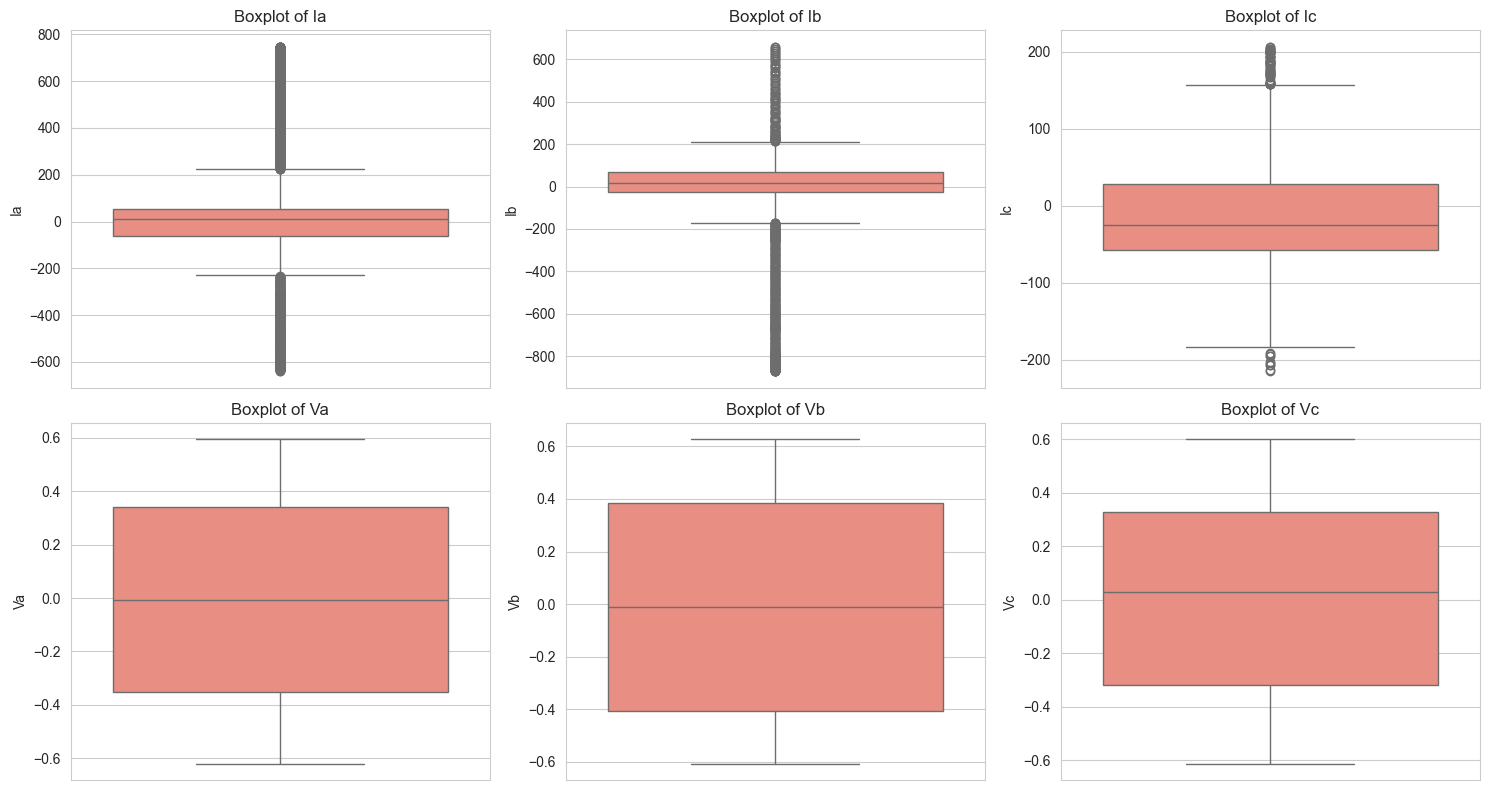

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), feature_cols):
    sns.boxplot(y=df[col], ax=ax, color='salmon')
    ax.set_title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

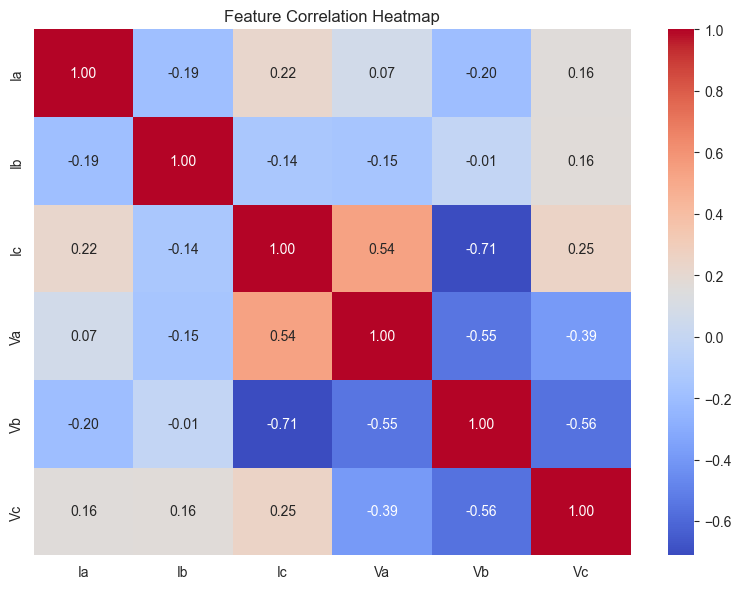

In [12]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[feature_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

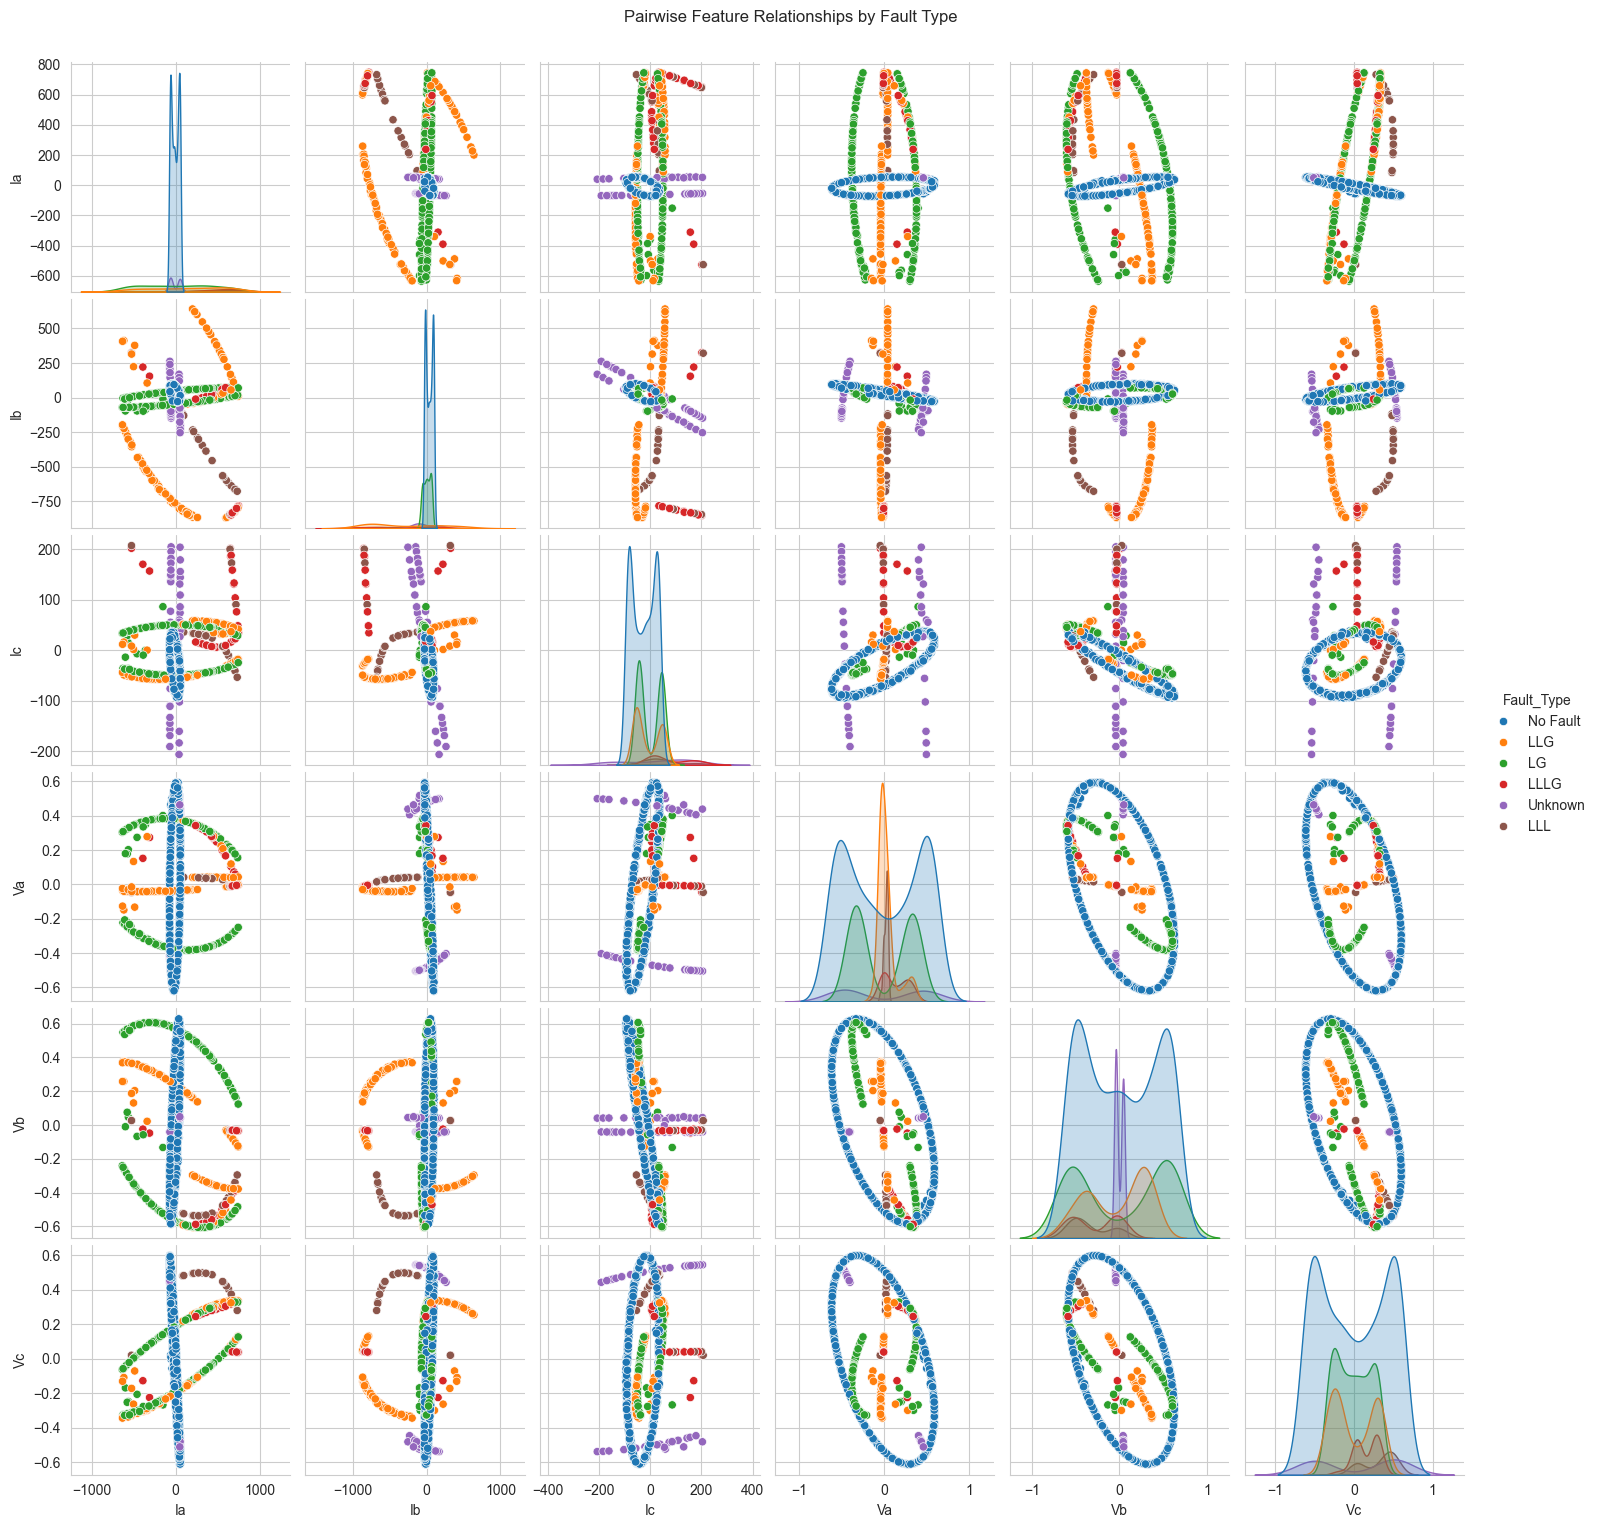

In [13]:
sample_df = df.sample(min(1000, len(df)), random_state=42)
sns.pairplot(sample_df, vars=feature_cols, hue='Fault_Type', diag_kind='kde', palette='tab10')
plt.suptitle('Pairwise Feature Relationships by Fault Type', y=1.02)
plt.show()

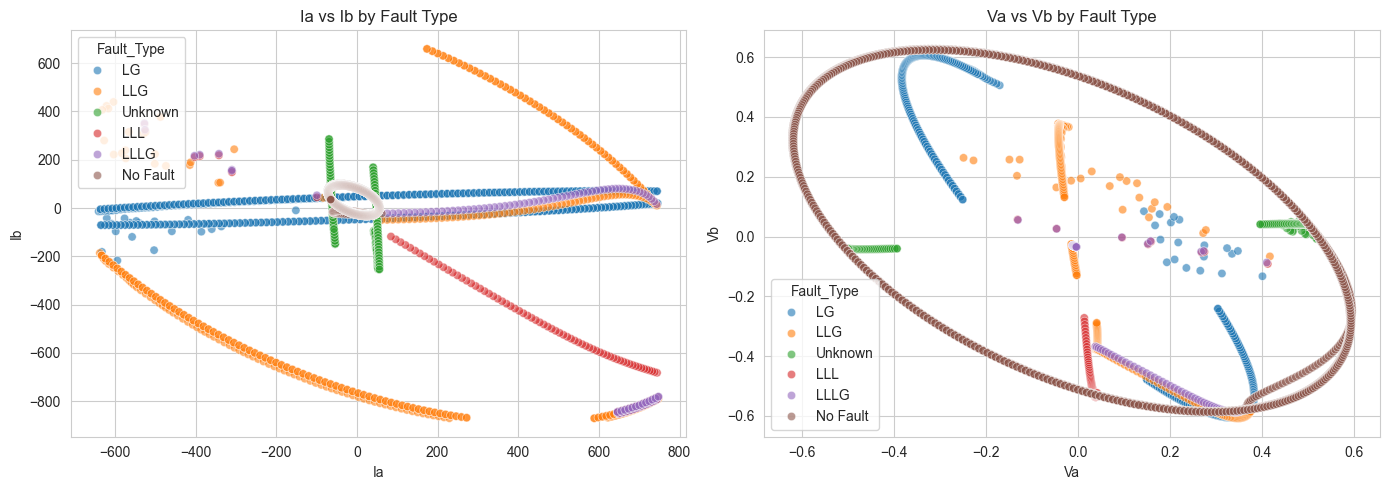

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df, x='Ia', y='Ib', hue='Fault_Type', ax=axes[0], palette='tab10', alpha=0.6)
axes[0].set_title('Ia vs Ib by Fault Type')
sns.scatterplot(data=df, x='Va', y='Vb', hue='Fault_Type', ax=axes[1], palette='tab10', alpha=0.6)
axes[1].set_title('Va vs Vb by Fault Type')
plt.tight_layout()
plt.show()

In [15]:
X = df[feature_cols]
le = LabelEncoder()
y = le.fit_transform(df['Fault_Type'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("Classes:", list(le.classes_))

X_train shape: (3116, 6)
X_test shape:  (779, 6)
Classes: ['LG', 'LLG', 'LLL', 'LLLG', 'No Fault', 'Unknown']



Logistic Regression
              precision    recall  f1-score   support

          LG       0.66      0.57      0.61       134
         LLG       0.93      0.55      0.69        93
         LLL       0.79      0.83      0.81        23
        LLLG       0.00      0.00      0.00        21
    No Fault       0.82      1.00      0.90       473
     Unknown       0.00      0.00      0.00        35

    accuracy                           0.80       779
   macro avg       0.53      0.49      0.50       779
weighted avg       0.74      0.80      0.76       779



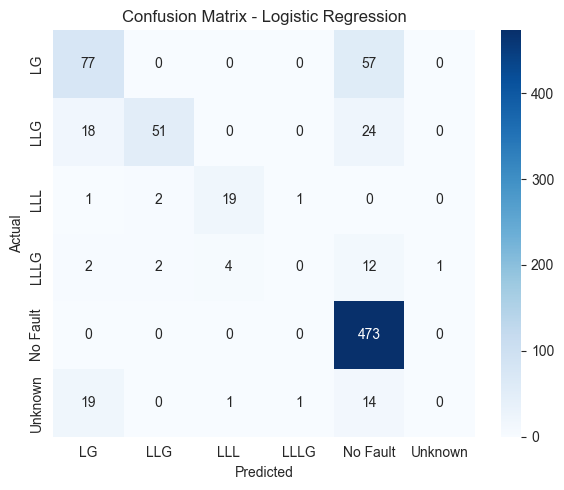


KNN
              precision    recall  f1-score   support

          LG       0.96      1.00      0.98       134
         LLG       1.00      0.94      0.97        93
         LLL       0.78      0.78      0.78        23
        LLLG       0.80      0.76      0.78        21
    No Fault       1.00      1.00      1.00       473
     Unknown       0.97      0.97      0.97        35

    accuracy                           0.98       779
   macro avg       0.92      0.91      0.91       779
weighted avg       0.98      0.98      0.98       779



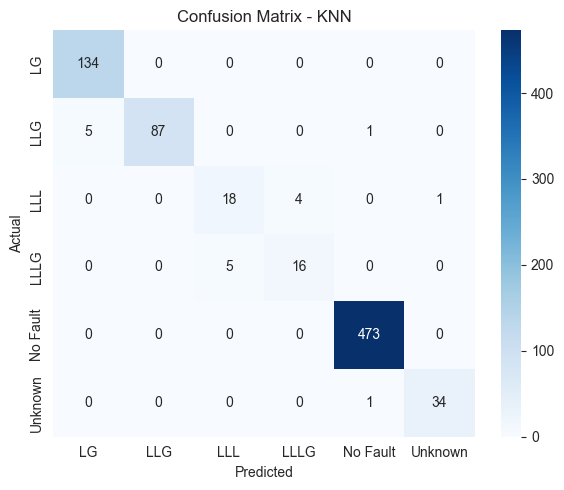


Decision Tree
              precision    recall  f1-score   support

          LG       0.96      1.00      0.98       134
         LLG       1.00      0.96      0.98        93
         LLL       0.91      0.87      0.89        23
        LLLG       0.90      0.86      0.88        21
    No Fault       1.00      1.00      1.00       473
     Unknown       0.97      1.00      0.99        35

    accuracy                           0.99       779
   macro avg       0.96      0.95      0.95       779
weighted avg       0.99      0.99      0.99       779



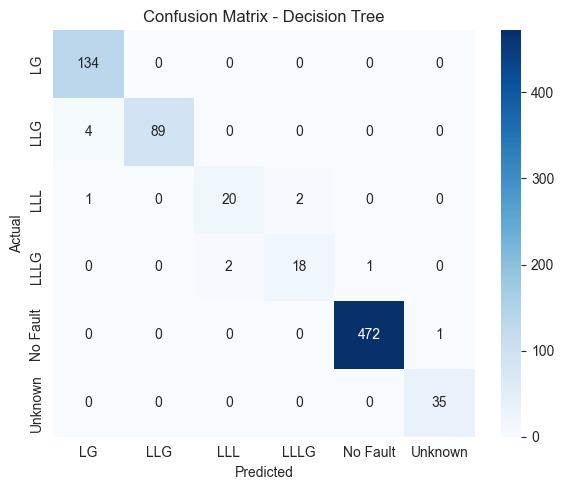


Random Forest
              precision    recall  f1-score   support

          LG       0.98      1.00      0.99       134
         LLG       1.00      0.96      0.98        93
         LLL       0.91      0.87      0.89        23
        LLLG       0.83      0.90      0.86        21
    No Fault       1.00      1.00      1.00       473
     Unknown       1.00      1.00      1.00        35

    accuracy                           0.99       779
   macro avg       0.95      0.96      0.95       779
weighted avg       0.99      0.99      0.99       779



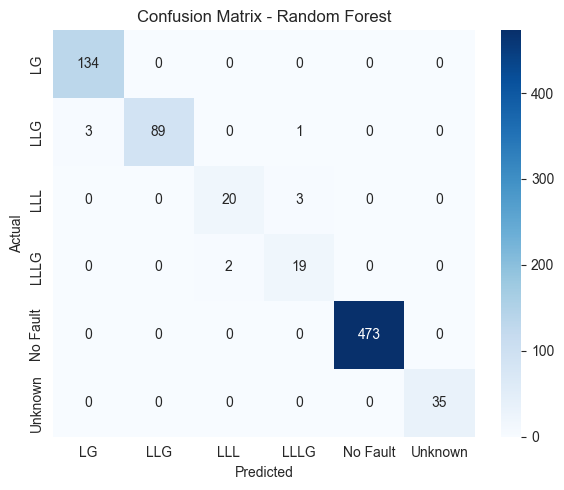


SVM
              precision    recall  f1-score   support

          LG       0.93      1.00      0.96       134
         LLG       1.00      0.91      0.96        93
         LLL       0.94      0.65      0.77        23
        LLLG       0.71      0.81      0.76        21
    No Fault       0.98      1.00      0.99       473
     Unknown       1.00      0.71      0.83        35

    accuracy                           0.96       779
   macro avg       0.93      0.85      0.88       779
weighted avg       0.96      0.96      0.96       779



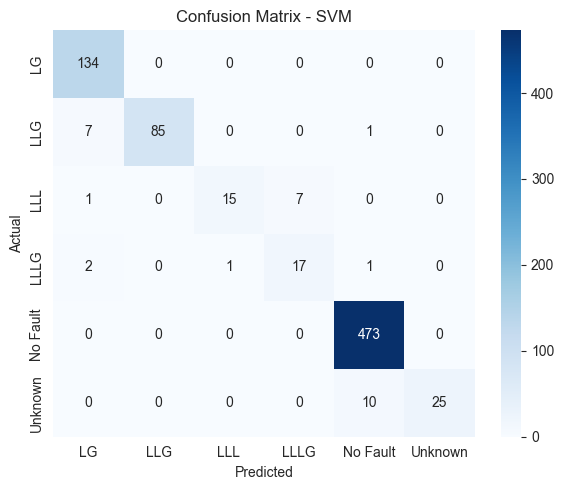


Gradient Boosting
              precision    recall  f1-score   support

          LG       0.96      1.00      0.98       134
         LLG       1.00      0.97      0.98        93
         LLL       0.91      0.87      0.89        23
        LLLG       0.90      0.86      0.88        21
    No Fault       1.00      1.00      1.00       473
     Unknown       1.00      1.00      1.00        35

    accuracy                           0.99       779
   macro avg       0.96      0.95      0.96       779
weighted avg       0.99      0.99      0.99       779



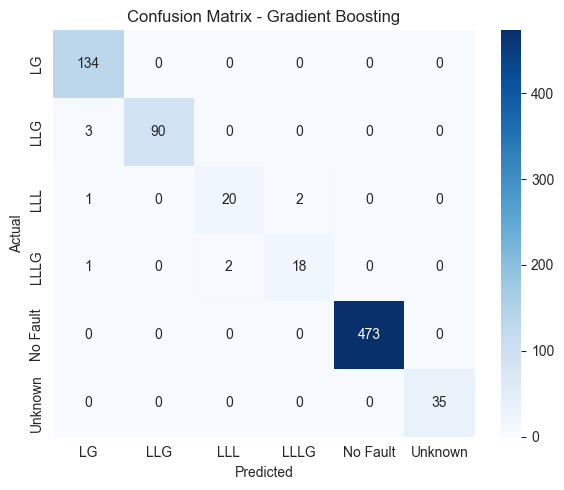


Naive Bayes
              precision    recall  f1-score   support

          LG       0.84      0.92      0.88       134
         LLG       0.98      0.66      0.79        93
         LLL       0.63      0.96      0.76        23
        LLLG       0.07      0.05      0.06        21
    No Fault       0.96      1.00      0.98       473
     Unknown       1.00      0.77      0.87        35

    accuracy                           0.91       779
   macro avg       0.75      0.72      0.72       779
weighted avg       0.91      0.91      0.90       779



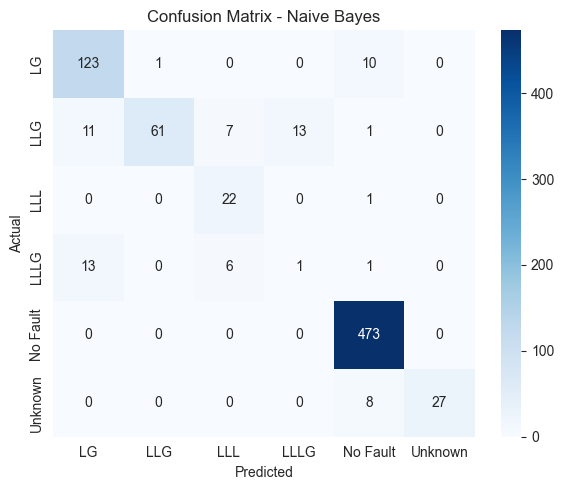


Model Comparison Table:


,Accuracy,Precision,Recall,F1-Score
Random Forest,0.988447,0.988861,0.988447,0.988515
Gradient Boosting,0.988447,0.988433,0.988447,0.988324
Decision Tree,0.985879,0.985901,0.985879,0.985741
KNN,0.978177,0.978162,0.978177,0.977969
SVM,0.961489,0.963323,0.961489,0.959950
Naive Bayes,0.907574,0.908180,0.907574,0.901630
Logistic Regression,0.795892,0.742455,0.795892,0.757178


In [16]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Naive Bayes': GaussianNB(),
}

results = {}
model_objects = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}
    model_objects[name] = model

    print(f"\n{'='*55}\n{name}\n{'='*55}")
    print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

results_df = pd.DataFrame(results).T.sort_values('Accuracy', ascending=False)
print("\nModel Comparison Table:")
display(results_df)

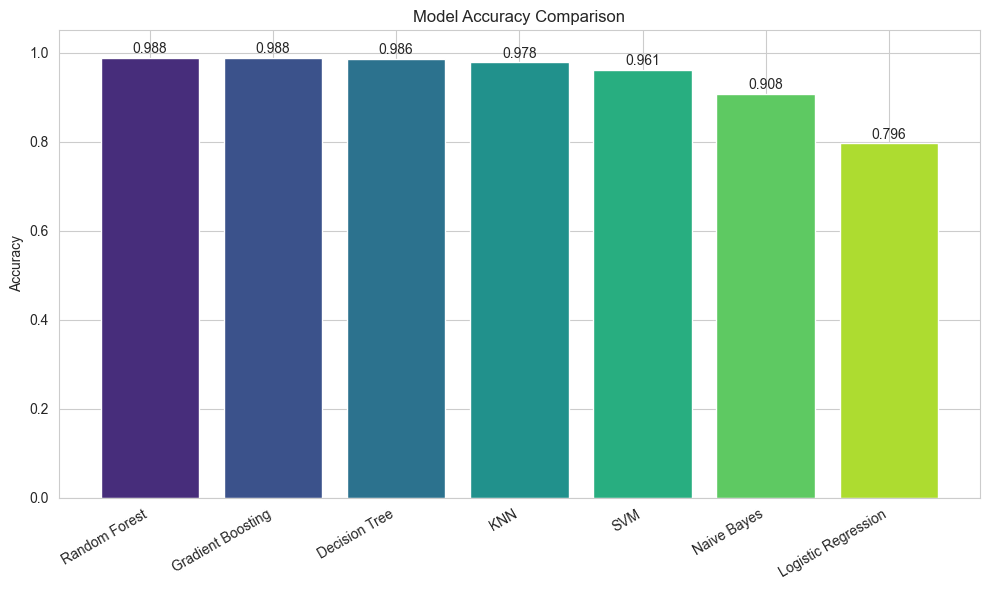

In [17]:
plt.figure(figsize=(10, 6))
bars = plt.bar(results_df.index, results_df['Accuracy'],
               color=sns.color_palette('viridis', len(results_df)))
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 1.05)
for bar, acc in zip(bars, results_df['Accuracy']):
    plt.text(bar.get_x() + bar.get_width() / 2, acc + 0.01, f'{acc:.3f}', ha='center')
plt.tight_layout()
plt.show()

In [18]:
best_model_name = results_df['Accuracy'].idxmax()
best_model = model_objects[best_model_name]
print("Best model:", best_model_name)

train_pred = best_model.predict(X_train)
test_pred = best_model.predict(X_test)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print(f"\nTrain Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Gap: {(train_acc - test_acc):.4f}")

if (train_acc - test_acc) > 0.10:
    verdict = "OVERFITTING"
elif train_acc < 0.80 and test_acc < 0.80:
    verdict = "UNDERFITTING"
else:
    verdict = "GOOD FIT"
print("\nVerdict:", verdict)

Best model: Random Forest

Train Accuracy: 1.0000
Test Accuracy:  0.9884
Gap: 0.0116

Verdict: GOOD FIT


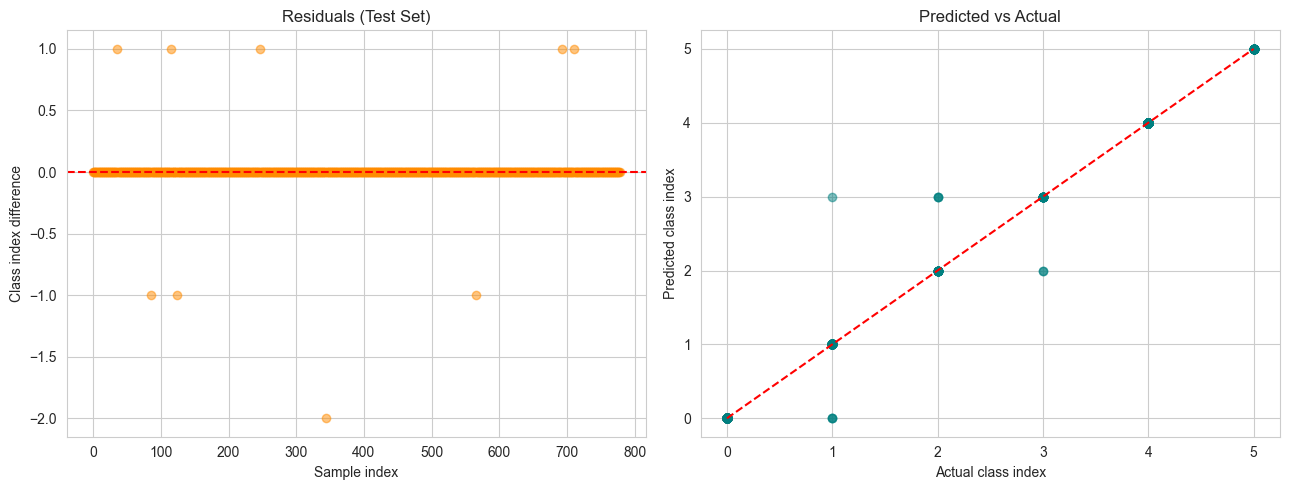

In [19]:
residuals_test = y_test - test_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(range(len(residuals_test)), residuals_test, alpha=0.5, color='darkorange')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuals (Test Set)')
axes[0].set_xlabel('Sample index')
axes[0].set_ylabel('Class index difference')

axes[1].scatter(y_test, test_pred, alpha=0.5, color='teal')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1].set_title('Predicted vs Actual')
axes[1].set_xlabel('Actual class index')
axes[1].set_ylabel('Predicted class index')
plt.tight_layout()
plt.show()

In [20]:
random.seed(42)
sample_idx = random.sample(range(len(X_test)), 5)

sample_X = X_test[sample_idx]
actual_labels = le.inverse_transform(np.array(y_test)[sample_idx])
predicted_labels = le.inverse_transform(best_model.predict(sample_X))

comparison = pd.DataFrame({'Actual': actual_labels, 'Predicted': predicted_labels})
comparison['Correct'] = comparison['Actual'] == comparison['Predicted']
comparison['Error %'] = comparison['Correct'].apply(lambda x: 0.0 if x else 100.0)
display(comparison)
print(f"\nSample error rate: {(1 - comparison['Correct'].mean()) * 100:.1f}%")

,Actual,Predicted,Correct,Error %
0,No Fault,No Fault,True,0.0
1,No Fault,No Fault,True,0.0
2,No Fault,No Fault,True,0.0
3,No Fault,No Fault,True,0.0
4,No Fault,No Fault,True,0.0



Sample error rate: 0.0%


In [21]:
print("Enter the following measured values to predict the fault type:")
Ia = float(input("Ia: "))
Ib = float(input("Ib: "))
Ic = float(input("Ic: "))
Va = float(input("Va: "))
Vb = float(input("Vb: "))
Vc = float(input("Vc: "))

manual_input = pd.DataFrame([[Ia, Ib, Ic, Va, Vb, Vc]], columns=feature_cols)
manual_scaled = scaler.transform(manual_input)
prediction = best_model.predict(manual_scaled)
predicted_label = le.inverse_transform(prediction)[0]
print(f"\nPredicted Fault Type: {predicted_label}")

Enter the following measured values to predict the fault type:


Ia:  -151.2918124
Ib:  -9.677451563
Ic:  85.80016226
Va:  0.400749853
Vb:  -0.132934945
Vc:  -0.267814907



Predicted Fault Type: LG


In [22]:
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')
print("Saved: best_model.pkl, scaler.pkl, label_encoder.pkl")

Saved: best_model.pkl, scaler.pkl, label_encoder.pkl


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import random
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               AdaBoostClassifier, ExtraTreesClassifier,
                               BaggingClassifier)
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import (LinearDiscriminantAnalysis,
                                            QuadraticDiscriminantAnalysis)
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

print("Libraries imported successfully.")

Libraries imported successfully.



Logistic Regression
              precision    recall  f1-score   support

          LG       0.66      0.57      0.61       134
         LLG       0.93      0.55      0.69        93
         LLL       0.79      0.83      0.81        23
        LLLG       0.00      0.00      0.00        21
    No Fault       0.82      1.00      0.90       473
     Unknown       0.00      0.00      0.00        35

    accuracy                           0.80       779
   macro avg       0.53      0.49      0.50       779
weighted avg       0.74      0.80      0.76       779



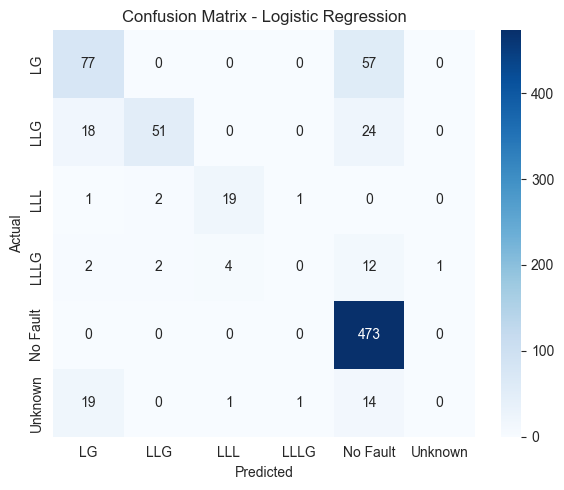


KNN
              precision    recall  f1-score   support

          LG       0.96      1.00      0.98       134
         LLG       1.00      0.94      0.97        93
         LLL       0.78      0.78      0.78        23
        LLLG       0.80      0.76      0.78        21
    No Fault       1.00      1.00      1.00       473
     Unknown       0.97      0.97      0.97        35

    accuracy                           0.98       779
   macro avg       0.92      0.91      0.91       779
weighted avg       0.98      0.98      0.98       779



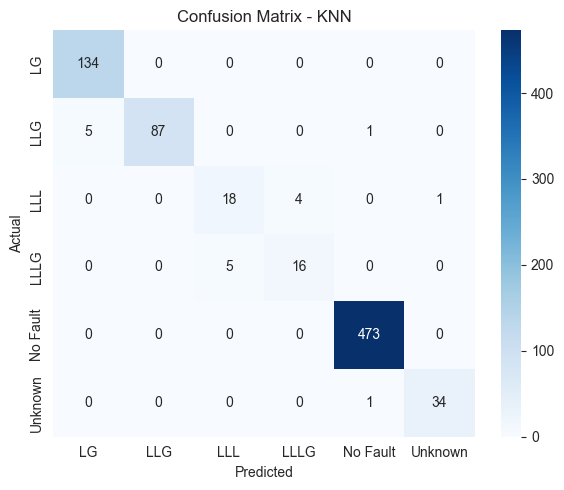


Decision Tree
              precision    recall  f1-score   support

          LG       0.96      1.00      0.98       134
         LLG       1.00      0.96      0.98        93
         LLL       0.91      0.87      0.89        23
        LLLG       0.90      0.86      0.88        21
    No Fault       1.00      1.00      1.00       473
     Unknown       0.97      1.00      0.99        35

    accuracy                           0.99       779
   macro avg       0.96      0.95      0.95       779
weighted avg       0.99      0.99      0.99       779



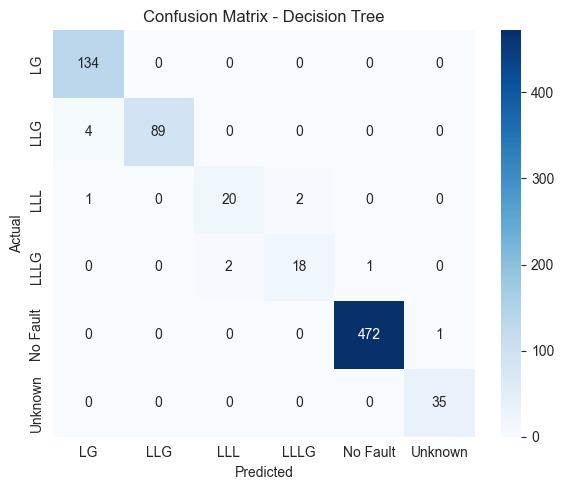


Random Forest
              precision    recall  f1-score   support

          LG       0.98      1.00      0.99       134
         LLG       1.00      0.96      0.98        93
         LLL       0.91      0.87      0.89        23
        LLLG       0.83      0.90      0.86        21
    No Fault       1.00      1.00      1.00       473
     Unknown       1.00      1.00      1.00        35

    accuracy                           0.99       779
   macro avg       0.95      0.96      0.95       779
weighted avg       0.99      0.99      0.99       779



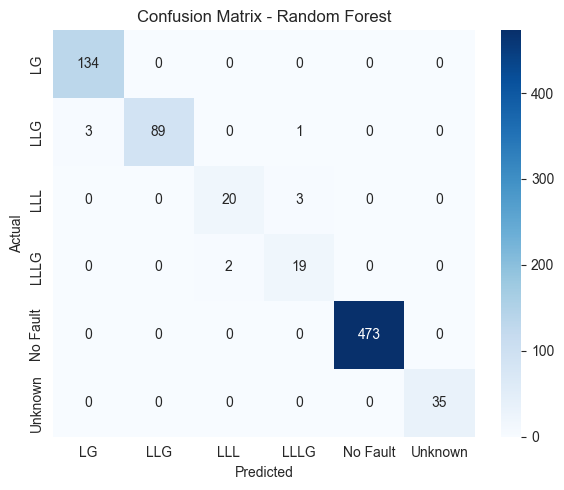


Extra Trees
              precision    recall  f1-score   support

          LG       1.00      1.00      1.00       134
         LLG       1.00      0.99      0.99        93
         LLL       0.91      0.87      0.89        23
        LLLG       0.82      0.86      0.84        21
    No Fault       1.00      1.00      1.00       473
     Unknown       1.00      1.00      1.00        35

    accuracy                           0.99       779
   macro avg       0.95      0.95      0.95       779
weighted avg       0.99      0.99      0.99       779



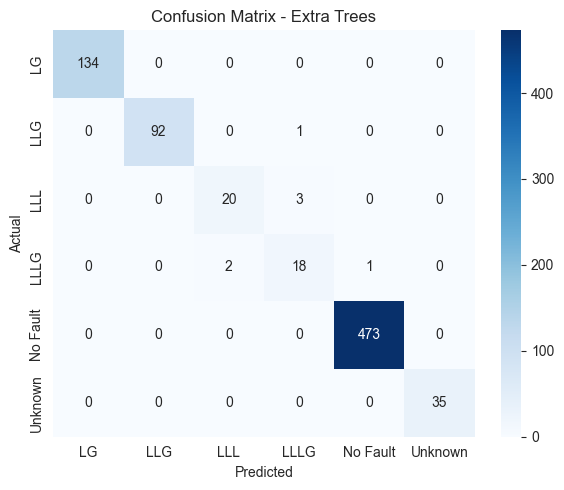


SVM
              precision    recall  f1-score   support

          LG       0.93      1.00      0.96       134
         LLG       1.00      0.91      0.96        93
         LLL       0.94      0.65      0.77        23
        LLLG       0.71      0.81      0.76        21
    No Fault       0.98      1.00      0.99       473
     Unknown       1.00      0.71      0.83        35

    accuracy                           0.96       779
   macro avg       0.93      0.85      0.88       779
weighted avg       0.96      0.96      0.96       779



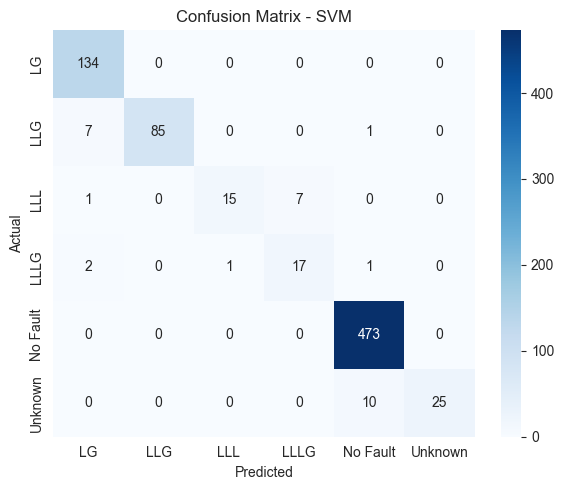


Gradient Boosting
              precision    recall  f1-score   support

          LG       0.96      1.00      0.98       134
         LLG       1.00      0.97      0.98        93
         LLL       0.91      0.87      0.89        23
        LLLG       0.90      0.86      0.88        21
    No Fault       1.00      1.00      1.00       473
     Unknown       1.00      1.00      1.00        35

    accuracy                           0.99       779
   macro avg       0.96      0.95      0.96       779
weighted avg       0.99      0.99      0.99       779



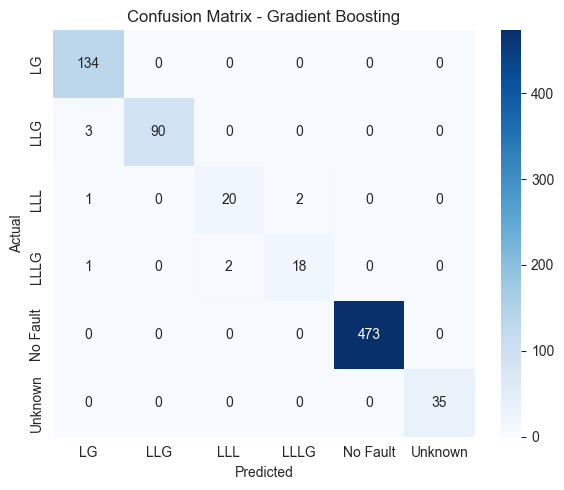


AdaBoost
              precision    recall  f1-score   support

          LG       0.50      0.21      0.29       134
         LLG       0.45      0.65      0.53        93
         LLL       0.39      0.30      0.34        23
        LLLG       0.00      0.00      0.00        21
    No Fault       0.83      1.00      0.91       473
     Unknown       1.00      0.09      0.16        35

    accuracy                           0.73       779
   macro avg       0.53      0.37      0.37       779
weighted avg       0.70      0.73      0.68       779



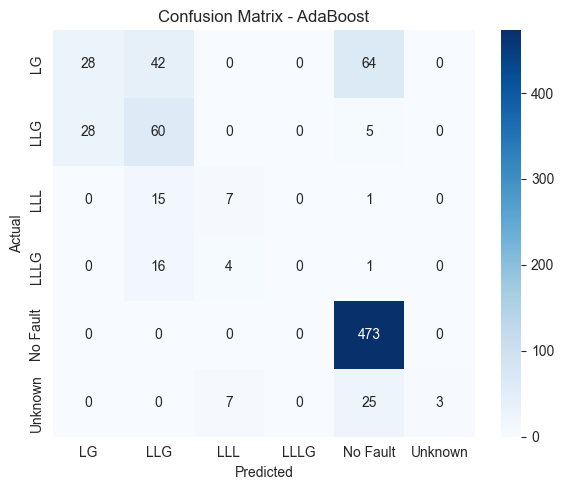


Bagging
              precision    recall  f1-score   support

          LG       0.96      1.00      0.98       134
         LLG       1.00      0.96      0.98        93
         LLL       0.91      0.87      0.89        23
        LLLG       0.90      0.90      0.90        21
    No Fault       1.00      1.00      1.00       473
     Unknown       1.00      1.00      1.00        35

    accuracy                           0.99       779
   macro avg       0.96      0.96      0.96       779
weighted avg       0.99      0.99      0.99       779



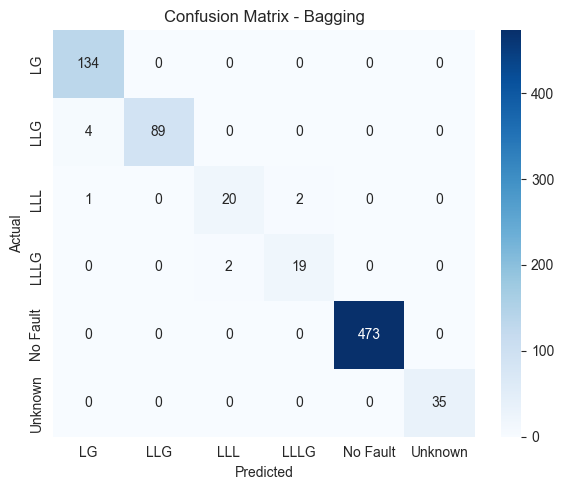


Naive Bayes
              precision    recall  f1-score   support

          LG       0.84      0.92      0.88       134
         LLG       0.98      0.66      0.79        93
         LLL       0.63      0.96      0.76        23
        LLLG       0.07      0.05      0.06        21
    No Fault       0.96      1.00      0.98       473
     Unknown       1.00      0.77      0.87        35

    accuracy                           0.91       779
   macro avg       0.75      0.72      0.72       779
weighted avg       0.91      0.91      0.90       779



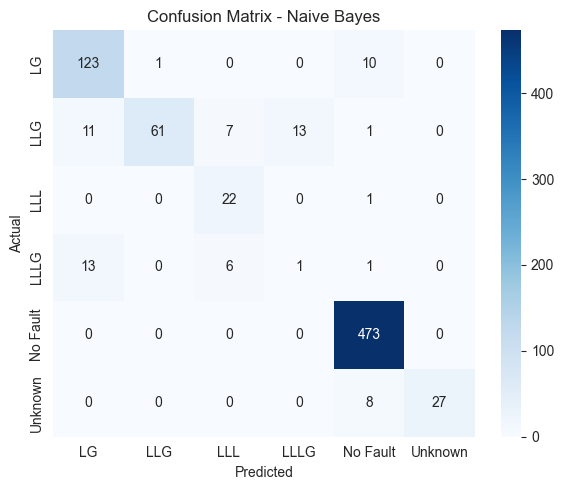


LDA
              precision    recall  f1-score   support

          LG       0.13      0.02      0.04       134
         LLG       0.87      0.43      0.58        93
         LLL       0.45      0.61      0.52        23
        LLLG       0.00      0.00      0.00        21
    No Fault       0.71      1.00      0.83       473
     Unknown       0.83      0.14      0.24        35

    accuracy                           0.69       779
   macro avg       0.50      0.37      0.37       779
weighted avg       0.61      0.69      0.61       779



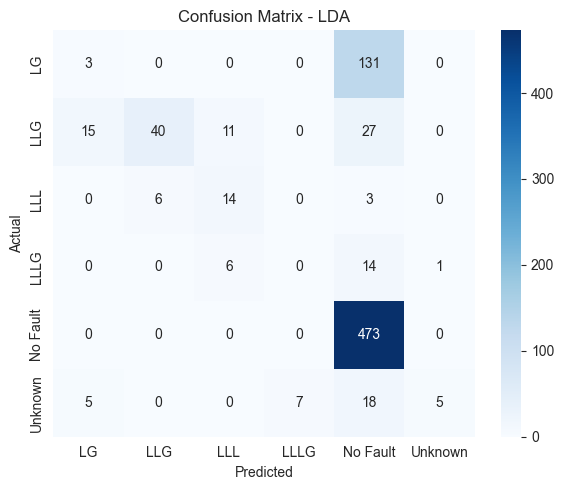


QDA
              precision    recall  f1-score   support

          LG       0.98      0.98      0.98       134
         LLG       0.99      0.92      0.96        93
         LLL       1.00      0.96      0.98        23
        LLLG       0.54      1.00      0.70        21
    No Fault       1.00      0.98      0.99       473
     Unknown       1.00      1.00      1.00        35

    accuracy                           0.97       779
   macro avg       0.92      0.97      0.93       779
weighted avg       0.98      0.97      0.97       779



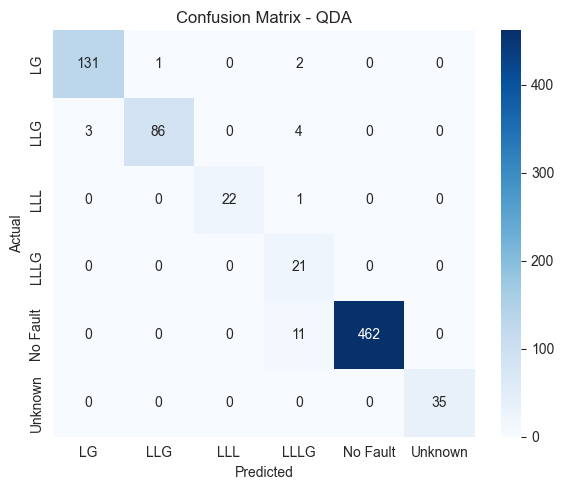


MLP (Neural Net)
              precision    recall  f1-score   support

          LG       0.98      1.00      0.99       134
         LLG       1.00      0.96      0.98        93
         LLL       0.80      0.87      0.83        23
        LLLG       0.80      0.76      0.78        21
    No Fault       1.00      1.00      1.00       473
     Unknown       1.00      0.97      0.99        35

    accuracy                           0.98       779
   macro avg       0.93      0.93      0.93       779
weighted avg       0.98      0.98      0.98       779



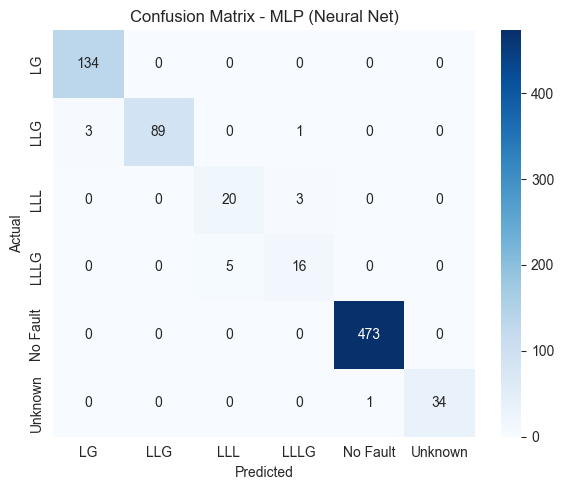


Model Comparison Table:


,Accuracy,Precision,Recall,F1-Score
Extra Trees,0.991014,0.991134,0.991014,0.991044
Random Forest,0.988447,0.988861,0.988447,0.988515
Gradient Boosting,0.988447,0.988433,0.988447,0.988324
Bagging,0.988447,0.988561,0.988447,0.988378
Decision Tree,0.985879,0.985901,0.985879,0.985741
MLP (Neural Net),0.983312,0.983656,0.983312,0.983341
KNN,0.978177,0.978162,0.978177,0.977969
QDA,0.971759,0.982335,0.971759,0.974956
SVM,0.961489,0.963323,0.961489,0.959950
Naive Bayes,0.907574,0.908180,0.907574,0.901630


In [25]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Extra Trees': ExtraTreesClassifier(random_state=42),
    'SVM': SVC(),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'Bagging': BaggingClassifier(random_state=42),
    'Naive Bayes': GaussianNB(),
    'LDA': LinearDiscriminantAnalysis(),
    'QDA': QuadraticDiscriminantAnalysis(),
    'MLP (Neural Net)': MLPClassifier(max_iter=500, random_state=42),
}

results = {}
model_objects = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}
    model_objects[name] = model

    print(f"\n{'='*55}\n{name}\n{'='*55}")
    print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

results_df = pd.DataFrame(results).T.sort_values('Accuracy', ascending=False)
print("\nModel Comparison Table:")
display(results_df)

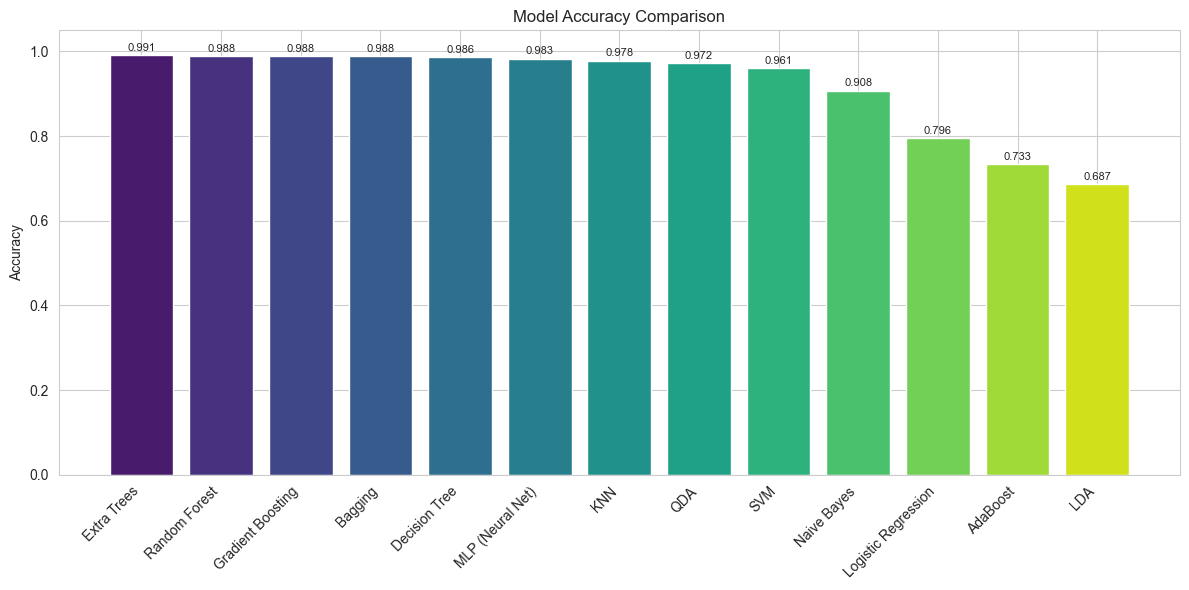

In [26]:
plt.figure(figsize=(12, 6))
bars = plt.bar(results_df.index, results_df['Accuracy'],
               color=sns.color_palette('viridis', len(results_df)))
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.05)
for bar, acc in zip(bars, results_df['Accuracy']):
    plt.text(bar.get_x() + bar.get_width() / 2, acc + 0.01, f'{acc:.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

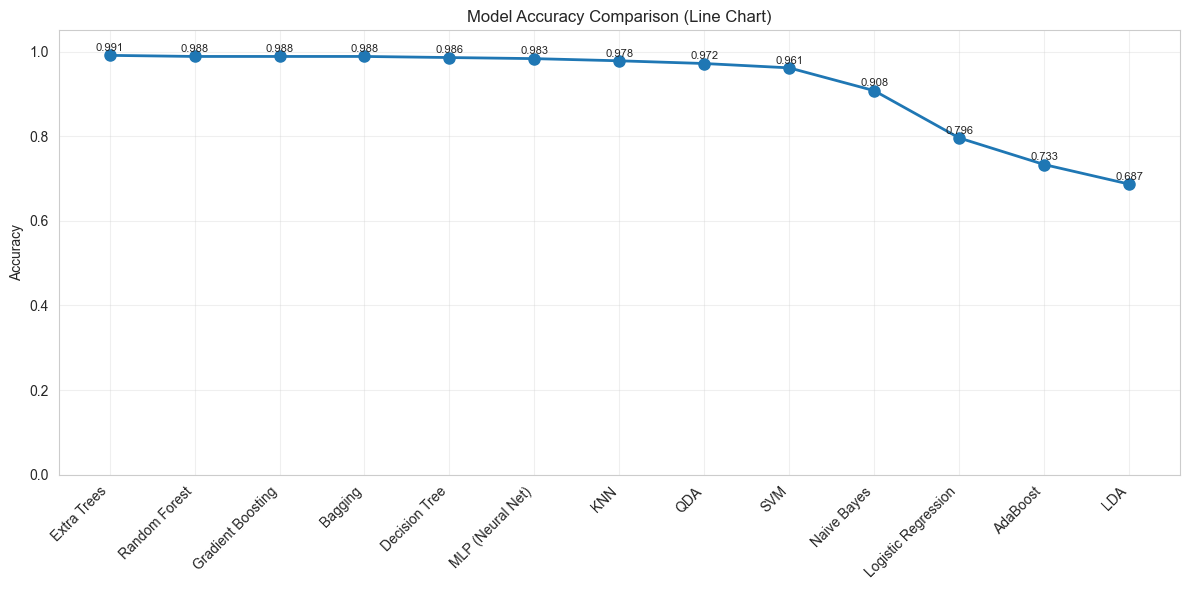

In [27]:
plt.figure(figsize=(12, 6))
plt.plot(results_df.index, results_df['Accuracy'], marker='o', linewidth=2,
         color='#1f77b4', markersize=8)

for x, acc in zip(results_df.index, results_df['Accuracy']):
    plt.text(x, acc + 0.01, f'{acc:.3f}', ha='center', fontsize=8)

plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison (Line Chart)')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

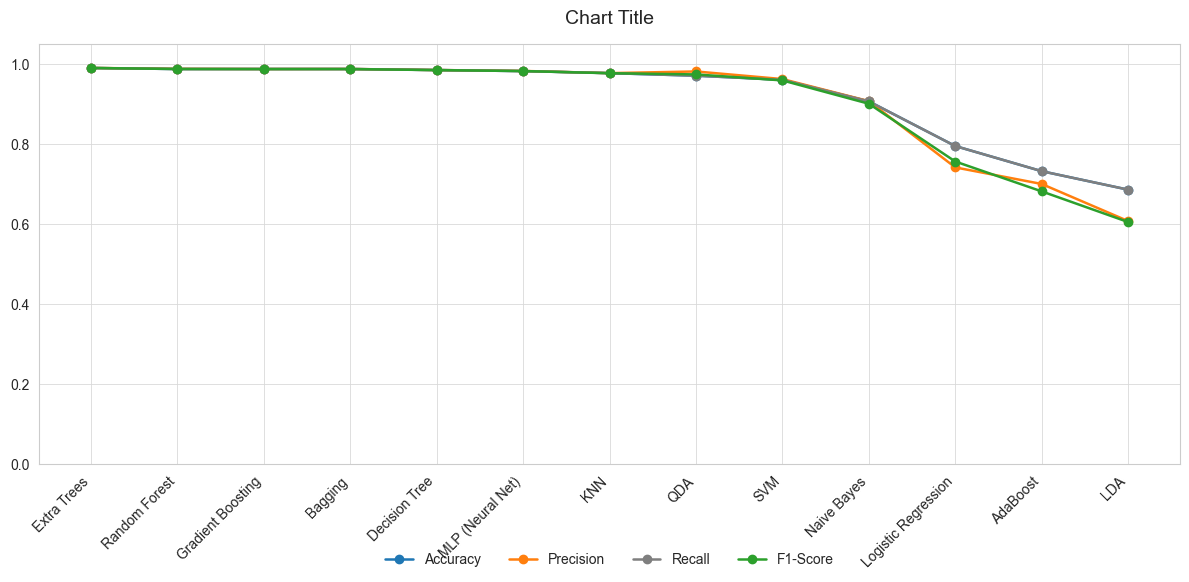

In [28]:
plt.figure(figsize=(12, 6))

colors = ['#1f77b4', '#ff7f0e', '#7f7f7f', '#2ca02c']
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

for metric, color in zip(metrics, colors):
    plt.plot(results_df.index, results_df[metric], marker='o', linewidth=1.8,
             markersize=6, color=color, label=metric)

plt.title('Chart Title', fontsize=14, pad=15)
plt.ylim(0, 1.05)
plt.grid(True, color='#d9d9d9', linewidth=0.6)
plt.gca().set_facecolor('white')
plt.xticks(rotation=45, ha='right')

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=4, frameon=False)
plt.tight_layout()
plt.show()

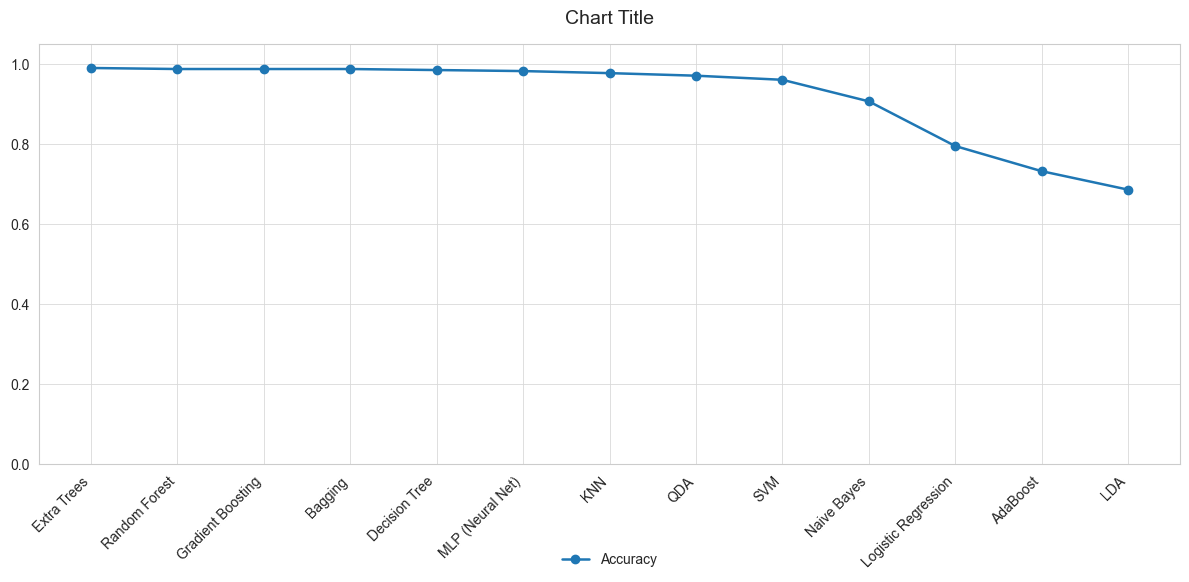

In [29]:
plt.figure(figsize=(12, 6))

plt.plot(results_df.index, results_df['Accuracy'], marker='o', linewidth=1.8,
         markersize=6, color='#1f77b4', label='Accuracy')

plt.title('Chart Title', fontsize=14, pad=15)
plt.ylim(0, 1.05)
plt.grid(True, color='#d9d9d9', linewidth=0.6)
plt.gca().set_facecolor('white')
plt.xticks(rotation=45, ha='right')

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=1, frameon=False)
plt.tight_layout()
plt.show()